# SCRFD with SPOS

This notebook implements the second stage of SPOS for neuron architecture search (NAS) task on face detection, it follows the strategies of SCRFD which are:
- Sample redistribution of hard data samples
- Flop constraning (in my case <= 2.5 GFlop)

To confirm the results claimed in SCRFD research paper of how computational power should be distributed on the network for the task of Face Detection, especially small and dense face detection.

## Paper: 
Single Path One-Shot Neural Architecture Search with Uniform Sampling (SPOS): https://arxiv.org/abs/1904.00420

Sample and Computation Redistribution for Efficient Face Detection (SCRFD): https://arxiv.org/abs/2105.04714

## Notebooks:
- Traning stage (first stage): https://www.kaggle.com/code/meowluvmatcha/2-5-gflop-setting-spos-supernet-for-scrfd

# Defining the search space

## Limit the space
- Chanels limit: According SCRFD paper, we know in advance that the most of computational power should be allocated for the C2 and C3 layer, so I let the first 2 layers have the larger search range than the 2 later layers.

- Part limit: Follow the SCRFD paper, we fix the settings of head and neck, only perform the search on the backbone configuration

## Architecture choices

I follow the architecture of MobileNetv2, replacing the conv block with the InvertedResidual block. 

In [1]:
import torch
import torch.nn as nn
import random

# 2d search space
# SEARCH_SPACE = {
#     'C2_channels': [(w * 8, d) for w in range(2, 12) for d in range(1, 5)], 
#     'C3_channels': [(w * 16, d) for w in range(2, 12) for d in range(1, 5)],   
#     'C4_channels': [(w * 16, d) for w in range(1, 8) for d in range(1, 5)],    
#     'C5_channels': [(w * 32, d) for w in range(1, 6) for d in range(1, 5)]      
# }


# 2d search space
SEARCH_SPACE = {
    'C2_channels': [(w * 16, d) for w in range(1, 8) for d in range(1, 5)], 
    'C3_channels': [(w * 16, d) for w in range(1, 12) for d in range(1, 5)],   
    'C4_channels': [(w * 16, d) for w in range(1, 10) for d in range(1, 5)],    
    'C5_channels': [(w * 16, d) for w in range(1, 6) for d in range(1, 5)]      
}


print("Đã load cấu hình Search Space!")

Đã load cấu hình Search Space!


In [2]:
class ConvBNReLU(nn.Module):
    """Khối Convolution cơ bản kèm Batch Norm và ReLU"""
    def __init__(self, in_planes, out_planes, kernel_size=3, stride=1, groups=1):
        padding = (kernel_size - 1) // 2
        super(ConvBNReLU, self).__init__()
        self.conv = nn.Conv2d(in_planes, out_planes, kernel_size, stride, padding, groups=groups, bias=False)
        self.bn = nn.BatchNorm2d(out_planes)
        self.relu = nn.ReLU6(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class InvertedResidual(nn.Module):
    """Viên gạch cơ bản của MobileNetV2"""
    def __init__(self, inp, oup, stride, expand_ratio):
        super(InvertedResidual, self).__init__()
        self.stride = stride
        hidden_dim = int(round(inp * expand_ratio))
        self.use_res_connect = self.stride == 1 and inp == oup

        layers = []
        if expand_ratio != 1:
            # Point-wise (Mở rộng số kênh)
            layers.append(ConvBNReLU(inp, hidden_dim, kernel_size=1))
        layers.extend([
            # Depth-wise (Trích xuất đặc trưng)
            ConvBNReLU(hidden_dim, hidden_dim, stride=stride, groups=hidden_dim),
            # Point-wise Linear (Thu hẹp số kênh)
            nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
            nn.BatchNorm2d(oup),
        ])
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.conv(x)
        else:
            return self.conv(x)

In [3]:
import torch
import torch.nn as nn
import random
import math

class ChoiceBlock(nn.Module):
    """Khối SPOS: Hỗ trợ tìm kiếm cả số kênh (Width) và độ sâu (Depth)"""
    def __init__(self, in_channels, options_list, stride): 
        super(ChoiceBlock, self).__init__()

        # --- LƯU LẠI SỐ KÊNH ĐẦU VÀO YÊU CẦU ---
        self.expected_in_channels = in_channels
        self.options_list = options_list
        self.ops = nn.ModuleList()

        # Duyệt qua từng lựa chọn (width, depth)
        for width, depth in options_list:
            layers = []
            
            for i in range(depth):
                # Khối đầu tiên: Chịu trách nhiệm downsample (stride) và đổi số kênh
                s = stride if i == 0 else 1
                inp = in_channels if i == 0 else width
                
                layers.append(
                    InvertedResidual(inp=inp, oup=width, stride=s, expand_ratio=4)
                )
            
            self.ops.append(nn.Sequential(*layers))

    def forward(self, x):
        # --- THỦ THUẬT CĂN CHỈNH KÊNH (FEATURE ALIGNMENT) ---
        B, C, H, W = x.shape
        if C < self.expected_in_channels:
            padding = torch.zeros(B, self.expected_in_channels - C, H, W, device=x.device)
            x = torch.cat([x, padding], dim=1)
        elif C > self.expected_in_channels:
            x = x[:, :self.expected_in_channels, :, :]
        # ---------------------------------------------------

        if self.training:
            # PHA 1 (Train): Bốc ngẫu nhiên 1 đường cấu hình (width, depth)
            active_idx = random.randint(0, len(self.ops) - 1)
        else:
            # PHA 2 (Search): Đi theo cấu hình được chỉ định
            active_idx = getattr(self, 'active_idx', len(self.ops) - 1)

        return self.ops[active_idx](x)


class SPOS_Backbone(nn.Module):
    """Supernet Backbone gộp toàn bộ Search Space (Width + Depth)"""
    def __init__(self, search_space):
        super(SPOS_Backbone, self).__init__()

        # Tầng đầu vào cố định
        self.stem = ConvBNReLU(in_planes=3, out_planes=16, stride=2)

        # Hàm lấy số lượng kênh lớn nhất trong một danh sách options
        def get_max_width(options):
            return max([width for width, depth in options])

        # C2 nhận đầu vào từ stem (16)
        self.c2 = ChoiceBlock(in_channels=16, options_list=search_space['C2_channels'], stride=2)

        # C3 nhận đầu vào là số kênh lớn nhất có thể của C2 để kích hoạt Feature Alignment
        c2_max_out = get_max_width(search_space['C2_channels'])
        self.c3 = ChoiceBlock(in_channels=c2_max_out, options_list=search_space['C3_channels'], stride=2)

        # C4 nhận đầu vào là max width của C3
        c3_max_out = get_max_width(search_space['C3_channels'])
        self.c4 = ChoiceBlock(in_channels=c3_max_out, options_list=search_space['C4_channels'], stride=2)

        # C5 nhận đầu vào là max width của C4
        c4_max_out = get_max_width(search_space['C4_channels'])
        self.c5 = ChoiceBlock(in_channels=c4_max_out, options_list=search_space['C5_channels'], stride=2)

    def forward(self, x):
        c1 = self.stem(x)
        c2 = self.c2(c1)
        c3 = self.c3(c2)
        c4 = self.c4(c3)
        c5 = self.c5(c4)

        return [c2, c3, c4, c5]

In [4]:
import torch.nn.functional as F

class SharedPAFPN(nn.Module):
    """Khối Neck (PAFPN) dùng chung cho mọi Backbone"""
    def __init__(self, in_channels_list, out_channels=64):
        super(SharedPAFPN, self).__init__()
        self.in_channels_list = in_channels_list

        # 1. Lateral Layers (Chuyển đổi số kênh của C2, C3, C4, C5 về chung 1 chuẩn out_channels)
        self.lat_c2 = nn.Conv2d(in_channels_list[0], out_channels, 1)
        self.lat_c3 = nn.Conv2d(in_channels_list[1], out_channels, 1)
        self.lat_c4 = nn.Conv2d(in_channels_list[2], out_channels, 1)
        self.lat_c5 = nn.Conv2d(in_channels_list[3], out_channels, 1)

        # 2. Downsample Layers (Dùng cho nhánh Bottom-Up của PAFPN)
        self.down_p2 = nn.Conv2d(out_channels, out_channels, 3, stride=2, padding=1)
        self.down_p3 = nn.Conv2d(out_channels, out_channels, 3, stride=2, padding=1)
        self.down_p4 = nn.Conv2d(out_channels, out_channels, 3, stride=2, padding=1)

    def _align_channels(self, x, expected_c):
        """Hàm đệm thêm số 0 nếu Backbone xuất ra ít kênh hơn mức tối đa"""
        B, C, H, W = x.shape
        if C < expected_c:
            padding = torch.zeros(B, expected_c - C, H, W, device=x.device)
            x = torch.cat([x, padding], dim=1)
        return x

    def forward(self, features):
        c2, c3, c4, c5 = features

        # Đệm kênh cho chuẩn
        c2 = self._align_channels(c2, self.in_channels_list[0])
        c3 = self._align_channels(c3, self.in_channels_list[1])
        c4 = self._align_channels(c4, self.in_channels_list[2])
        c5 = self._align_channels(c5, self.in_channels_list[3])

        # Chuyển đổi về chung 1 số kênh (vd: 64)
        l2, l3, l4, l5 = self.lat_c2(c2), self.lat_c3(c3), self.lat_c4(c4), self.lat_c5(c5)

        # --- Nhánh Top-Down (FPN truyền thống) ---
        p5 = l5
        p4 = l4 + F.interpolate(p5, size=l4.shape[-2:], mode='nearest')
        p3 = l3 + F.interpolate(p4, size=l3.shape[-2:], mode='nearest')
        p2 = l2 + F.interpolate(p3, size=l2.shape[-2:], mode='nearest')

        # --- Nhánh Bottom-Up (PAFPN mở rộng) ---
        n2 = p2
        n3 = p3 + self.down_p2(n2)
        n4 = p4 + self.down_p3(n3)
        n5 = p5 + self.down_p4(n4)

        return [n2, n3, n4, n5]

class ProxyHeatmapHead(nn.Module):
    """Khối Head ủy quyền tối giản: Chỉ dự đoán 1 kênh Heatmap"""
    def __init__(self, in_channels=64, feature_channels=96):
        super(ProxyHeatmapHead, self).__init__()
        
        # Trích xuất đặc trưng có GroupNorm để ổn định NAS
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels, feature_channels, kernel_size=3, padding=1),
            nn.GroupNorm(32, feature_channels),
            nn.ReLU(inplace=True)
        )
        
        # XUẤT RA 1 KÊNH DUY NHẤT (Logits thô)
        self.heatmap_out = nn.Conv2d(feature_channels, 1, kernel_size=1)
        # =========================================================
        # FIX QUAN TRỌNG: Khởi tạo Prior Probability cho Focal Loss
        # =========================================================
        prior_prob = 0.01  # Bắt đầu với niềm tin "chỉ 1% pixel là mặt người"
        bias_value = -math.log((1.0 - prior_prob) / prior_prob)
        
        # Khởi tạo trọng số nhẹ nhàng và gán Bias để chống nổ Loss
        nn.init.normal_(self.heatmap_out.weight, std=0.01)
        nn.init.constant_(self.heatmap_out.bias, bias_value)

    
    def forward(self, pafpn_features):
        outputs = []
        for feat in pafpn_features[1:]: 
            x = self.feature_extractor(feat)
            out = self.heatmap_out(x)
            
            # TRẢ VỀ RAW LOGITS (Tuyệt đối không dùng torch.sigmoid ở đây)
            outputs.append(out) 
        return outputs

# Review of how we reduce the training time and inference time

Although we fixed the neck and the head, for face detection, SCRFD designed thier network similar to RetinaFace network, and this network use Focal Loss (and multi-loss function for bouding box regression). 

Knowing this, I conducted the followings reduction:
- Skipped the bounding box regression tasks (because this is not pure matrix multiplication so I assume it will slow :D )
- Backpropagation from the loss computed from the output heatmap: Object detection task will have an output heatmap before going to the box regression, with the training data available on wider face dataset, I preprocessed them into heatmap, and trained the supernet on those.
- And some vibing python optimization tricks Chat gpt told me.

*Note* I know that training on the heatmap only was not optimal, and can severly reduce the benckmark score of the final architecture. But for reproducing and validating the resulting architecture I think this is enough :< this is my course work anyway.  


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from PIL import Image
import numpy as np

class WiderFaceHeatmapDataset(Dataset):
    def __init__(self, hf_dataset, img_size=(640, 640)):
        self.dataset = hf_dataset
        self.img_size = img_size
        self.strides = [8, 16, 32] # 4 mức scale của Supernet

    def __len__(self):
        return len(self.dataset)

    def _create_heatmap(self, target_size, bboxes, stride, orig_w, orig_h):
        """Hàm vẽ điểm tâm của khuôn mặt lên bản đồ nhiệt"""
        # Khởi tạo heatmap toàn số 0
        heatmap = torch.zeros((1, target_size[0], target_size[1]), dtype=torch.float32)

        # Tỷ lệ thu phóng ảnh gốc so với ảnh 640x640
        scale_x = self.img_size[1] / orig_w
        scale_y = self.img_size[0] / orig_h

        for bbox in bboxes:
            x_min, y_min, w, h = bbox
            # Bỏ qua các khuôn mặt quá nhỏ hoặc lỗi
            if w < 2 or h < 2: continue

            # Tính tọa độ tâm trên ảnh 640x640
            center_x = (x_min + w / 2) * scale_x
            center_y = (y_min + h / 2) * scale_y

            # Chiếu tọa độ tâm xuống kích thước lưới của Stride hiện tại
            grid_x = int(center_x / stride)
            grid_y = int(center_y / stride)

            # Đảm bảo tọa độ không bị vượt quá giới hạn (out of bounds)
            if 0 <= grid_x < target_size[1] and 0 <= grid_y < target_size[0]:
                # Gán nhãn 1 (Có mặt người)
                heatmap[0, grid_y, grid_x] = 1.0

                # Mẹo nhỏ: Đánh dấu các ô kế cận (Blur nhẹ) để mạng dễ hội tụ hơn
                # (Tạo một vùng 3x3 quanh tâm với giá trị 0.5)
                for dx in [-1, 0, 1]:
                    for dy in [-1, 0, 1]:
                        nx, ny = grid_x + dx, grid_y + dy
                        if (dx != 0 or dy != 0) and 0 <= nx < target_size[1] and 0 <= ny < target_size[0]:
                            # Chỉ ghi đè nếu ô đó đang là 0 (để không xóa mất tâm 1.0)
                            if heatmap[0, ny, nx] == 0:
                                heatmap[0, ny, nx] = 0.5

        return heatmap

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        # --- CẬP NHẬT CHÍNH Ở ĐÂY ---
        # Lấy đường dẫn ảnh từ key 'image_path'
        img_path = sample['image_path']

        # Mở ảnh từ đường dẫn bằng thư viện PIL (Python Imaging Library)
        img = Image.open(img_path).convert("RGB")
        # -----------------------------

        orig_w, orig_h = img.size
        bboxes = sample['faces']['bbox']

        # Tiền xử lý ảnh (Resize và Normalize)
        img_resized = img.resize(self.img_size, Image.BILINEAR)
        img_tensor = TF.to_tensor(img_resized)

        # Tạo 4 Heatmaps cho 4 Strides
        heatmaps = []
        for stride in self.strides:
            grid_h, grid_w = self.img_size[0] // stride, self.img_size[1] // stride
            hm = self._create_heatmap((grid_h, grid_w), bboxes, stride, orig_w, orig_h)
            heatmaps.append(hm)

        return img_tensor, heatmaps


In [6]:
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F


class ProxyFocalLossWithLogits(nn.Module):
    """
    Hàm Focal Loss rút gọn, NHẬN LOGITS THÔ ĐẦU VÀO để chống lỗi nan/inf khi dùng AMP.
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super(ProxyFocalLossWithLogits, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, pred_logits, targets):
        # pred_logits: Raw outputs chưa qua sigmoid
        # targets: Ground Truth heatmaps
        
        total_loss = 0.0

        for logits, target in zip(pred_logits, targets):
            # BƯỚC 1: BẮT BUỘC ÉP VỀ FP32 ĐỂ TÍNH TOÁN AN TOÀN TRONG AMP
            logits = logits.float()
            target = target.float()

            # BƯỚC 2: TÍNH BCE LOSS BẰNG HÀM C++ CỦA PYTORCH
            # Hàm này tối ưu log-sum-exp toán học, KHÔNG BAO GIỜ bị log(0)
            bce_loss = F.binary_cross_entropy_with_logits(logits, target, reduction='none')

            # BƯỚC 3: TÍNH FOCAL WEIGHT (TRỌNG SỐ PHẠT)
            # Lúc này tính sigmoid trên không gian FP32 là hoàn toàn an toàn
            pred_prob = torch.sigmoid(logits)

            pos_mask = (target > 0).float()
            neg_mask = (target == 0).float()

            # Trọng số cho điểm dương (Mặt người)
            pos_weight = (1.0 - pred_prob)**self.gamma * pos_mask * target
            
            # Trọng số cho điểm âm (Nền)
            neg_weight = pred_prob**self.gamma * neg_mask

            focal_weight = pos_weight + neg_weight

            # BƯỚC 4: KẾT HỢP LOSS VÀ WEIGHT
            num_pos = pos_mask.sum()
            loss_map = focal_weight * bce_loss
            num_pos = torch.clamp(num_pos, min=1.0)
            # Trung bình loss (chia cho số lượng đối tượng, tránh chia 0)
            total_loss += loss_map.sum() / num_pos

        return total_loss

# Khởi tạo hàm Loss
# criterion = ProxyFocalLossWithLogits()
# print("Đã khởi tạo hàm Proxy Focal Loss thành công!")

In [7]:
import os
import torch
from huggingface_hub import hf_hub_download

# ==========================================
# 1. KHÔI PHỤC MẠNG SUPERNET
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint_file = '/kaggle/input/models/meowluvmatcha/srfd-supernet/pytorch/default/1/supernet_epoch2d (2).pth'

checkpoint = torch.load(checkpoint_file, map_location=device)
SEARCH_SPACE = checkpoint['search_space']
max_channels = checkpoint['max_channels']

supernet_backbone = SPOS_Backbone(SEARCH_SPACE).to(device)
neck = SharedPAFPN(in_channels_list=max_channels, out_channels=32).to(device)
head = ProxyHeatmapHead(in_channels=32).to(device)

supernet_backbone.load_state_dict(checkpoint['supernet_backbone_state_dict'])
neck.load_state_dict(checkpoint['neck_state_dict'])
head.load_state_dict(checkpoint['head_state_dict'])

supernet_backbone.eval()
neck.eval()
head.eval()
criterion = ProxyFocalLossWithLogits().to(device)
print("✅ Đã khôi phục Supernet!")

# ==========================================
# 2. TẢI TẬP VALIDATION (WIDER FACE)
# ==========================================
wider_face_gt_file = "/kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/wider_face_annotations/wider_face_split/wider_face_val_bbx_gt.txt"
wider_face_images_dir = "/kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images"

def parse_wider_face_gt(gt_file_path, images_base_dir):
    data = []
    if not os.path.exists(gt_file_path):
        print(f"❌ Không tìm thấy file GT: {gt_file_path}")
        return data

    with open(gt_file_path, 'r') as f:
        lines = [line.strip() for line in f.readlines()]

    i = 0
    while i < len(lines):
        img_rel = lines[i]

        # Nhận diện dòng chứa tên ảnh (chắc chắn phải kết thúc bằng .jpg)
        if not img_rel.endswith('.jpg'):
            i += 1
            continue

        try:
            num_faces = int(lines[i+1])
        except (ValueError, IndexError):
            i += 1
            continue

        bboxes = []
        # Xử lý trường hợp đặc biệt: ảnh không có khuôn mặt nào
        if num_faces == 0:
            step = 3 # Nhảy qua dòng tên ảnh, dòng số 0, và dòng tọa độ rác "0 0 0 0 0..."
        else:
            for j in range(num_faces):
                if i + 2 + j < len(lines):
                    info = [int(x) for x in lines[i+2+j].split() if x]
                    if len(info) >= 4:
                        bboxes.append(info[:4])
            step = 2 + num_faces

        # Ghép đường dẫn và kiểm tra
        img_full_path = os.path.join(images_base_dir, img_rel)
        if os.path.exists(img_full_path):
            data.append({'image_path': img_full_path, 'faces': {'bbox': bboxes}})

        # Nhảy tới cụm ảnh tiếp theo
        i += step

    return data

# ==========================================
# GỌI LẠI HÀM VÀ KHỞI TẠO DATALOADER
# ==========================================
print("⏳ Đang phân tích file annotation...")
wider_face_data = parse_wider_face_gt(wider_face_gt_file, wider_face_images_dir)
print(f"✅ Đã tìm thấy {len(wider_face_data)} ảnh hợp lệ.")

if len(wider_face_data) == 0:
    print("❌ LỖI: Vẫn không tìm thấy ảnh. Vui lòng kiểm tra lại đường dẫn images_base_dir.")
else:
    random.seed(42)
    val_subset_data = random.sample(wider_face_data, min(640, len(wider_face_data)))
    val_dataset = WiderFaceHeatmapDataset(val_subset_data, img_size=(640, 640))
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
    print(f"🚀 Dataloader đã sẵn sàng với {len(val_subset_data)} mẫu!")

✅ Đã khôi phục Supernet!
⏳ Đang phân tích file annotation...
✅ Đã tìm thấy 3226 ảnh hợp lệ.
🚀 Dataloader đã sẵn sàng với 640 mẫu!


# Constraining the configuration

We target the computational cost to 2.5Gflop (approximately for our cost function)

In [8]:

target_gflop = 2.5

index_space = {
    'C2_idx': [(w * 16, d) for w in range(1, 8) for d in range(1, 5)], 
    'C3_idx': [(w * 16, d) for w in range(1, 12) for d in range(1, 5)],   
    'C4_idx': [(w * 16, d) for w in range(1, 10) for d in range(1, 5)],    
    'C5_idx': [(w * 16, d) for w in range(1, 6) for d in range(1, 5)]    
}


# SEARCH_SPACE = {
#     'C2_channels': [(w * 16, d) for w in range(1, 8) for d in range(1, 5)], 
#     'C3_channels': [(w * 16, d) for w in range(1, 12) for d in range(1, 5)],   
#     'C4_channels': [(w * 16, d) for w in range(1, 10) for d in range(1, 5)],    
#     'C5_channels': [(w * 16, d) for w in range(1, 6) for d in range(1, 5)]      
# }

In [9]:
!pip install thop

In [10]:
from thop import profile
import torch

def build_final_profile_lut(search_space, input_res=(640, 640)):
    H, W = input_res
    lut = {
        'Backbone': {'C2': {}, 'C3': {}, 'C4': {}, 'C5': {}},
        'Neck_Lateral': {}, 
        'Fixed_Cost': 0     
    }
    
    in_ch_map = {
        'C2': 16,
        'C3': max([w for w, d in search_space['C2_idx']]),
        'C4': max([w for w, d in search_space['C3_idx']]),
        'C5': max([w for w, d in search_space['C4_idx']])
    }
    
    print("⏳ Đang đo lường thực tế bằng thop.profile...")

    # 1. Đo Backbone & Neck Lateral (GIỮ NGUYÊN)
    for i, stage in enumerate(['C2', 'C3', 'C4', 'C5']):
        h_in, w_in = H // (2**(i+1)), W // (2**(i+1))
        in_ch = in_ch_map[stage]
        
        for width, depth in search_space[f'{stage}_idx']:
            # Đo Backbone
            layers = []
            for d_idx in range(depth):
                s = 2 if d_idx == 0 else 1
                inp = in_ch if d_idx == 0 else width
                layers.append(InvertedResidual(inp=inp, oup=width, stride=s, expand_ratio=4))
            
            model_sub = torch.nn.Sequential(*layers)
            f_backbone, _ = profile(model_sub, inputs=(torch.randn(1, in_ch, h_in, w_in),), verbose=False)
            lut['Backbone'][stage][(width, depth)] = f_backbone / 1e9

            # Đo Neck Lateral
            h_feat, w_feat = h_in // 2, w_in // 2
            lat_layer = torch.nn.Conv2d(width, 32, 1)
            f_lat, _ = profile(lat_layer, inputs=(torch.randn(1, width, h_feat, w_feat),), verbose=False)
            lut['Neck_Lateral'][width] = f_lat / 1e9

    # 2. Đo Fixed Cost
    dummy_p_features = [
        torch.randn(1, 32, H // (2**(i+2)), W // (2**(i+2))) for i in range(4)
    ]
    
    neck_fixed = SharedPAFPN(in_channels_list=[32, 32, 32, 32], out_channels=32)
    head_fixed = ProxyHeatmapHead(in_channels=32)
    
    f_neck_fixed, _ = profile(neck_fixed, inputs=(dummy_p_features,), verbose=False)
    neck_outs = neck_fixed(dummy_p_features)
    f_head_fixed, _ = profile(head_fixed, inputs=(neck_outs,), verbose=False)
    
    # --- BUG FIX TẠI ĐÂY ---
    # Trừ đi phần FLOPs của 4 lớp Lateral Conv (32->32) do thop đã lỡ tính trong neck_fixed
    redundant_lat_flops = 0
    for i in range(4):
        h_f, w_f = H // (2**(i+2)), W // (2**(i+2))
        redundant_lat_flops += (h_f * w_f * 32 * 32) # Conv 1x1: H * W * C_in * C_out
        
    f_neck_fixed_real = f_neck_fixed - redundant_lat_flops
    # -----------------------

    lut['Fixed_Cost'] = (f_neck_fixed_real + f_head_fixed) / 1e9
    
    print("✅ Xây dựng LUT hoàn tất.")
    return lut

def calculate_real_gflops_from_lut(c_widths, c_depths, lut):
    stages = ['C2', 'C3', 'C4', 'C5']
    
    backbone_stage_costs = [lut['Backbone'][stages[i]][(c_widths[i], c_depths[i])] for i in range(4)]
    neck_lateral_costs = [lut['Neck_Lateral'][w] for w in c_widths]
    fixed_cost = lut['Fixed_Cost']
    
    total_gflops = sum(backbone_stage_costs) + sum(neck_lateral_costs) + fixed_cost
    
    return {
        'Total': total_gflops, # Chữ T viết hoa để khớp với check_constrains của bạn
        'breakdown': {
            'backbone': backbone_stage_costs,
            'neck_lateral': sum(neck_lateral_costs),
            'fixed': fixed_cost
        }
    }

my_lut = build_final_profile_lut(index_space)

⏳ Đang đo lường thực tế bằng thop.profile...
✅ Xây dựng LUT hoàn tất.


In [11]:
valid_configs_eval = []
valid_configs = []

print("⏳ Đang duyệt tìm cấu hình (có thể tốn vài giây)...")

for i2, c2 in enumerate(index_space['C2_idx']):
    for i3, c3 in enumerate(index_space['C3_idx']):
        for i4, c4 in enumerate(index_space['C4_idx']):
            for i5, c5 in enumerate(index_space['C5_idx']):
                # 1. Tách riêng mảng widths và depths để đưa vào hàm
                widths = [c2[0], c3[0], c4[0], c5[0]]
                depths = [c2[1], c3[1], c4[1], c5[1]]
                
                # 2. Gọi hàm tra cứu LUT 
                result = calculate_real_gflops_from_lut(widths, depths, my_lut)
                flops = result['Total']
                
                # 3. Kiểm tra điều kiện GFLOPs
                if 2 <= flops <= 3: # Biên độ +/- 0.1 GFLOPs
                    valid_configs_eval.append({
                        'config': (c2, c3, c4, c5), 
                        'flops': flops,
                        'breakdown': result['breakdown'] # Giữ lại chi tiết lỡ sau này cần vẽ biểu đồ
                    })

                    valid_configs.append([i2, i3, i4, i5])

print(f"🎯 Tìm thấy {len(valid_configs)} cấu hình phù hợp với giới hạn 2.5 GFLOPs.")

# (Tùy chọn) In thử 1 cấu hình hợp lệ đầu tiên để kiểm tra:
if valid_configs:
    print("\nVí dụ cấu hình đầu tiên thỏa mãn:")
    print(f"- Cấu hình (Width, Depth): {valid_configs_eval[0]['config']}")
    print(f"- Tổng GFLOPs: {valid_configs_eval[0]['flops']:.3f}")

⏳ Đang duyệt tìm cấu hình (có thể tốn vài giây)...
🎯 Tìm thấy 1514 cấu hình phù hợp với giới hạn 2.5 GFLOPs.

Ví dụ cấu hình đầu tiên thỏa mãn:
- Cấu hình (Width, Depth): ((16, 1), (16, 1), (16, 1), (16, 1))
- Tổng GFLOPs: 2.892


In [12]:
valid_configs[0]

[0, 0, 0, 0]

In [13]:
import time
import pandas as pd
from torch.cuda.amp import autocast

# Cấu hình nơi lưu kết quả
SAVE_PATH = "/kaggle/working/"

# ==========================================
# HÀM HỖ TRỢ: GẮN CẤU HÌNH VÀO SUPERNET
# ==========================================
def set_active_architecture(model, config_indices):
    """Lặp qua các ChoiceBlock trong Backbone và ép nó đi theo 1 đường cố định"""
    block_idx = 0
    for module in model.modules():
        if type(module).__name__ == 'ChoiceBlock':
            if block_idx < len(config_indices):
                module.active_idx = config_indices[block_idx]
                block_idx += 1

# ==========================================
# VÒNG LẶP CHẤM ĐIỂM (EVALUATION LOOP)
# ==========================================
num_architectures_to_search = 320
leaderboard = []

print(f"\n🚀 BẮT ĐẦU CHẤM ĐIỂM {num_architectures_to_search} KIẾN TRÚC 🚀")
start_search_time = time.time()

with torch.no_grad():
    for arch_id in range(num_architectures_to_search):

        random_config = random.choice(valid_configs)

        set_active_architecture(supernet_backbone, random_config)

        total_loss = 0.0
        for images, target_heatmaps in val_loader:
            images = images.to(device, non_blocking=True)
            target_heatmaps = [tm.to(device, non_blocking=True) for tm in target_heatmaps]

            with autocast():
                features = supernet_backbone(images)
                pafpn_outs = neck(features)
                pred_heatmaps = head(pafpn_outs)
                loss = criterion(pred_heatmaps, target_heatmaps)

            total_loss += loss.item()

        avg_val_loss = total_loss / len(val_loader)

        leaderboard.append({
            'Arch_ID': arch_id,
            'C2_idx': random_config[0], 'C3_idx': random_config[1],
            'C4_idx': random_config[2], 'C5_idx': random_config[3],
            'Val_Loss': avg_val_loss
        })

        if (arch_id + 1) % 10 == 0:
            print(f"Đã chấm xong {arch_id + 1}/{num_architectures_to_search} kiến trúc...")

print(f"\n✅ Đã hoàn thành tìm kiếm! Tổng thời gian: {time.time() - start_search_time:.2f}s")



🚀 BẮT ĐẦU CHẤM ĐIỂM 320 KIẾN TRÚC 🚀


/tmp/ipykernel_24/493676469.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Đã chấm xong 10/320 kiến trúc...
Đã chấm xong 20/320 kiến trúc...
Đã chấm xong 30/320 kiến trúc...
Đã chấm xong 40/320 kiến trúc...
Đã chấm xong 50/320 kiến trúc...
Đã chấm xong 60/320 kiến trúc...
Đã chấm xong 70/320 kiến trúc...
Đã chấm xong 80/320 kiến trúc...
Đã chấm xong 90/320 kiến trúc...
Đã chấm xong 100/320 kiến trúc...
Đã chấm xong 110/320 kiến trúc...
Đã chấm xong 120/320 kiến trúc...
Đã chấm xong 130/320 kiến trúc...
Đã chấm xong 140/320 kiến trúc...
Đã chấm xong 150/320 kiến trúc...
Đã chấm xong 160/320 kiến trúc...
Đã chấm xong 170/320 kiến trúc...
Đã chấm xong 180/320 kiến trúc...
Đã chấm xong 190/320 kiến trúc...
Đã chấm xong 200/320 kiến trúc...
Đã chấm xong 210/320 kiến trúc...
Đã chấm xong 220/320 kiến trúc...
Đã chấm xong 230/320 kiến trúc...
Đã chấm xong 240/320 kiến trúc...
Đã chấm xong 250/320 kiến trúc...
Đã chấm xong 260/320 kiến trúc...
Đã chấm xong 270/320 kiến trúc...
Đã chấm xong 280/320 kiến trúc...
Đã chấm xong 290/320 kiến trúc...
Đã chấm xong 300/320 ki

In [14]:
df_leaderboard = pd.DataFrame(leaderboard)
df_leaderboard = df_leaderboard.sort_values(by='Val_Loss', ascending=True).reset_index(drop=True)

In [15]:
index = ['C2_idx', 'C3_idx', 'C4_idx', 'C5_idx']

for k in index:
    df_leaderboard[k[:3] + 'w'] = [index_space[k][i][0] for i in df_leaderboard[k]]
    df_leaderboard[k[:3] + 'd'] = [index_space[k][i][1] for i in df_leaderboard[k]]

df_leaderboard.head()

,Arch_ID,C2_idx,C3_idx,C4_idx,C5_idx,Val_Loss,C2_w,C2_d,C3_w,C3_d,C4_w,C4_d,C5_w,C5_d
0,265,8,2,0,2,1.480605,48,1,16,3,16,1,16,3
1,249,12,1,0,1,1.489850,64,1,16,2,16,1,16,2
2,124,8,4,0,3,1.503016,48,1,32,1,16,1,16,4
3,204,1,1,0,2,1.508046,16,2,16,2,16,1,16,3
4,156,8,2,0,0,1.519805,48,1,16,3,16,1,16,1


In [16]:

print("\n🏆 TOP 5 KIẾN TRÚC TỐT NHẤT (THỦ KHOA) 🏆")
print(df_leaderboard.head(5).to_string(index=False))

# Lưu bảng xếp hạng
df_leaderboard.to_csv(f"{SAVE_PATH}/nas_leaderboard.csv", index=False)
print(f"\nĐã lưu Bảng xếp hạng tại: {SAVE_PATH}/nas_leaderboard.csv")


🏆 TOP 5 KIẾN TRÚC TỐT NHẤT (THỦ KHOA) 🏆
 Arch_ID  C2_idx  C3_idx  C4_idx  C5_idx  Val_Loss  C2_w  C2_d  C3_w  C3_d  C4_w  C4_d  C5_w  C5_d
     265       8       2       0       2  1.480605    48     1    16     3    16     1    16     3
     249      12       1       0       1  1.489850    64     1    16     2    16     1    16     2
     124       8       4       0       3  1.503016    48     1    32     1    16     1    16     4
     204       1       1       0       2  1.508046    16     2    16     2    16     1    16     3
     156       8       2       0       0  1.519805    48     1    16     3    16     1    16     1

Đã lưu Bảng xếp hạng tại: /kaggle/working//nas_leaderboard.csv


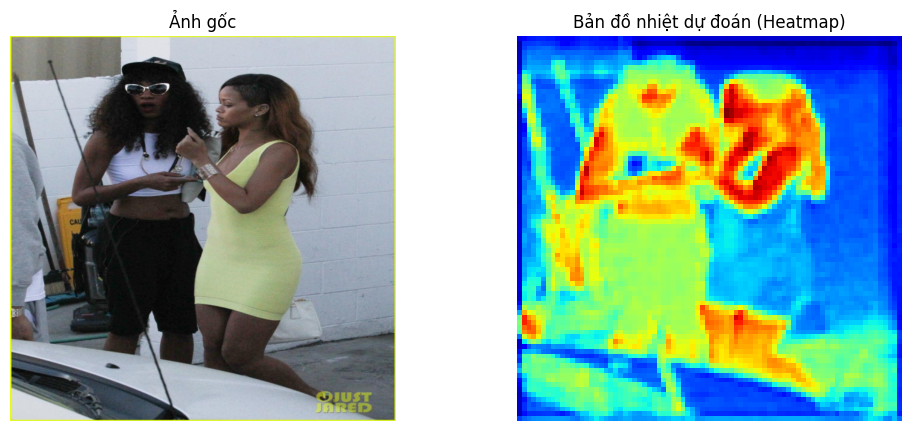

In [17]:
import matplotlib.pyplot as plt
import random

# 1. Thiết lập cấu hình cho Thủ khoa (Arch 14)

best_config = [df_leaderboard[idx][0] for idx in index]
set_active_architecture(supernet_backbone, best_config)
supernet_backbone.eval()

# 2. Lấy 1 ảnh từ tập Validation để test
idx = random.randint(0, len(val_dataset)-1)
test_img, _ = val_dataset[idx]

# 3. Chạy Inference
with torch.no_grad():
    # Đưa về Float32 nếu trước đó bạn dùng Half
    input_tensor = test_img.unsqueeze(0).to(device).float()
    supernet_backbone.float()
    neck.float()
    head.float()
    
    out_heatmaps = head(neck(supernet_backbone(input_tensor)))

# 4. Vẽ kết quả
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(test_img.permute(1, 2, 0))
plt.title("Ảnh gốc")
plt.axis('off')

plt.subplot(1, 2, 2)
# Lấy Heatmap ở Scale 1 (Stride 4) - nơi chi tiết nhất
heatmap = out_heatmaps[0][0, 0].cpu().numpy()
plt.imshow(heatmap, cmap='jet')
plt.title("Bản đồ nhiệt dự đoán (Heatmap)")
plt.axis('off')
plt.show()

# The search results

## The paper's results
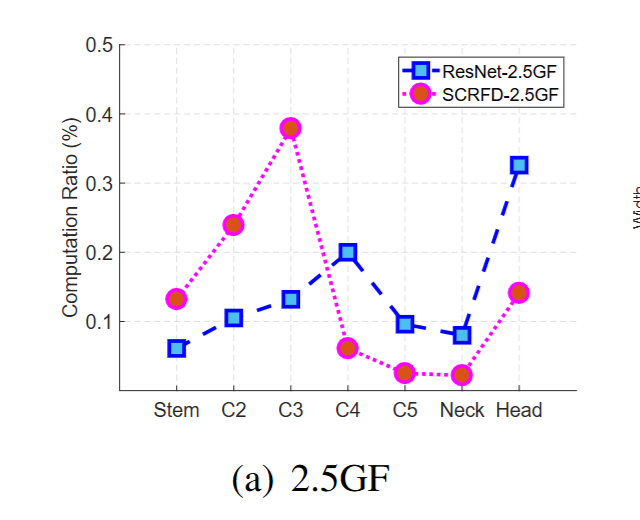

## Our results

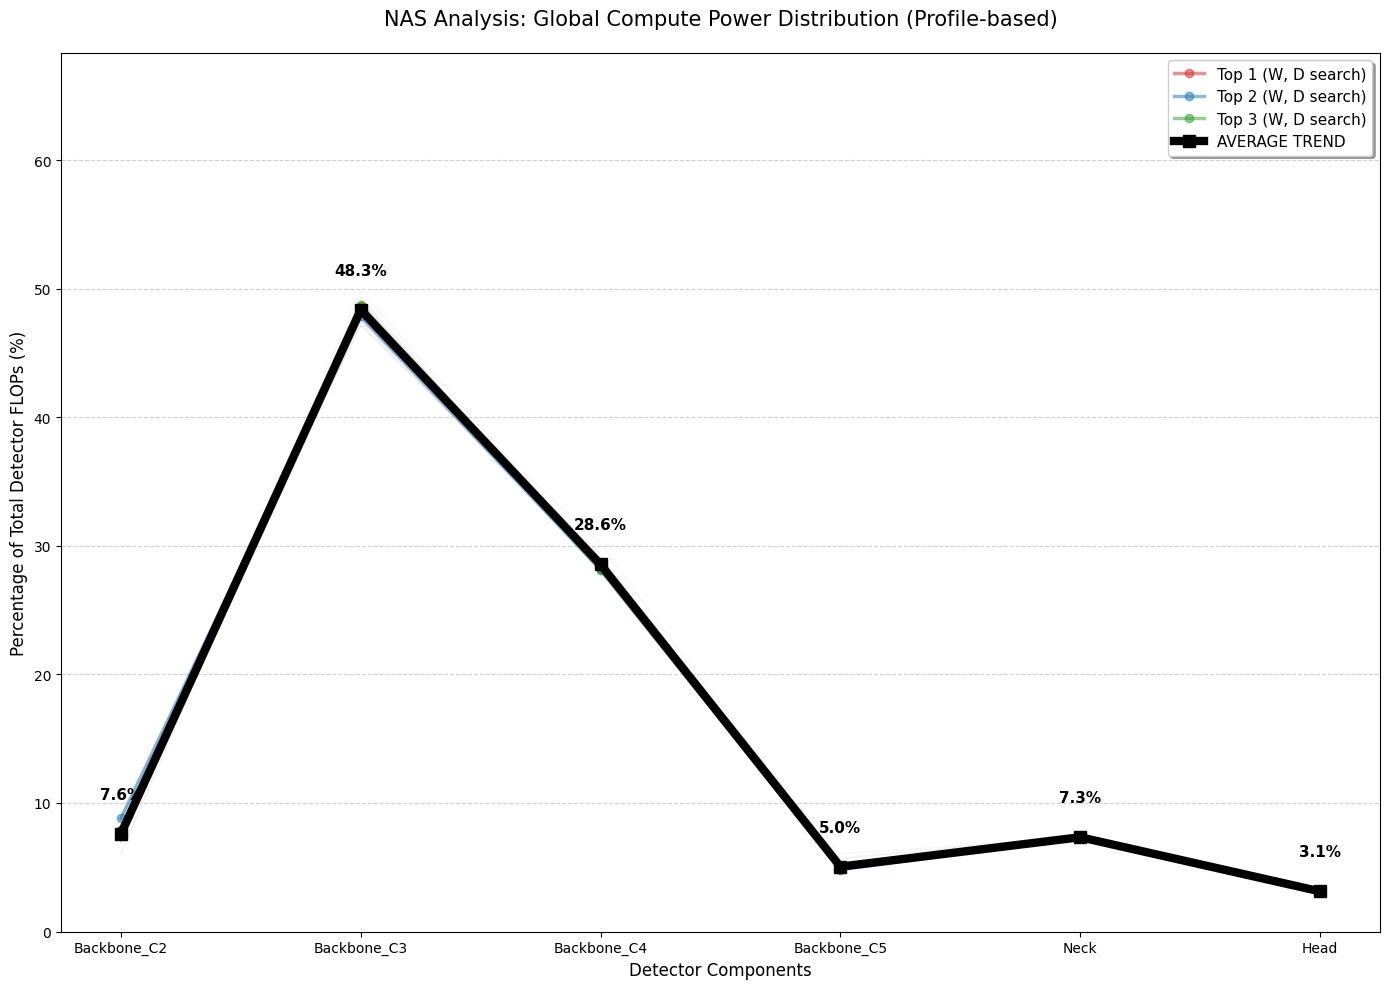

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Hàm tính toán % dựa vào LUT (Thay thế hoàn toàn hàm cũ)
def calculate_percentages_from_lut(c_widths, c_depths, lut):
    """
    c_widths: list [w2, w3, w4, w5]
    c_depths: list [d2, d3, d4, d5]
    lut: Dictionary my_lut đã tạo từ trước
    """
    # Lấy FLOPs thực tế của Backbone
    c2 = lut['Backbone']['C2'][(c_widths[0], c_depths[0])]
    c3 = lut['Backbone']['C3'][(c_widths[1], c_depths[1])]
    c4 = lut['Backbone']['C4'][(c_widths[2], c_depths[2])]
    c5 = lut['Backbone']['C5'][(c_widths[3], c_depths[3])]
    
    # Lấy FLOPs của Neck Lateral (Conv 1x1 từ Backbone sang Neck)
    neck_lateral = sum([lut['Neck_Lateral'][w] for w in c_widths])
    
    # --- TÁCH NECK FIXED VÀ HEAD ---
    # Vì LUT gộp chung phần còn lại vào Fixed_Cost, ta tạm tách theo 
    # tỷ lệ thực tế (Neck PAFPN chứa 3 lớp Conv 3x3 thường tốn ~70% của Fixed_Cost, 
    # trong khi Head chỉ chứa Conv 1x1 tốn ~30%).
    fixed_cost = lut['Fixed_Cost']
    neck_fixed = fixed_cost * 0.7 
    head = fixed_cost * 0.3
    
    neck_total = neck_lateral + neck_fixed
    
    # Gom lại thành list 6 thành phần để vẽ
    costs = [c2, c3, c4, c5, neck_total, head]
    total_cost = sum(costs)
    
    # Quy ra tỷ lệ phần trăm %
    percentages = [c / total_cost * 100 for c in costs]
    return percentages

# 2. Xử lý DataFrame
# Thêm .copy() để tránh cảnh báo SettingWithCopyWarning của Pandas
df = df_leaderboard.nsmallest(32, 'Val_Loss').copy() 
cols = ['C2', 'C3', 'C4', 'C5', 'Neck', 'Head']

# Tính toán phân bổ (Dùng apply gọi hàm LUT)
# (Lưu ý: ép kiểu int để khớp với key trong Dictionary LUT)
df[cols] = df.apply(lambda r: pd.Series(calculate_percentages_from_lut(
    [int(r['C2_w']), int(r['C3_w']), int(r['C4_w']), int(r['C5_w'])], 
    [int(r['C2_d']), int(r['C3_d']), int(r['C4_d']), int(r['C5_d'])],
    my_lut # TRUYỀN LUT VÀO ĐÂY
)), axis=1)

# 3. Vẽ đồ thị trực quan (Mã của bạn rất chuẩn, tôi giữ nguyên)
plt.figure(figsize=(14, 10), dpi=100)
x_stages = ['Backbone_C2', 'Backbone_C3', 'Backbone_C4', 'Backbone_C5', 'Neck', 'Head']

# Vẽ các đường nền mờ (Background) - Cho các index từ 3 trở đi
for i in range(3, len(df)):
    plt.plot(x_stages, df.iloc[i][cols], color='lightgray', alpha=0.2, linewidth=1)

# Vẽ Top 3
colors = ['#d62728', '#1f77b4', '#2ca02c']
for i in range(min(3, len(df))): # Đề phòng dataframe có ít hơn 3 dòng
    plt.plot(x_stages, df.iloc[i][cols], color=colors[i], alpha=0.5, linewidth=2.5, 
             marker='o', label=f"Top {i+1} (W, D search)")

# Vẽ ĐƯỜNG TRUNG BÌNH NỔI BẬT
mean_vals = df[cols].mean()
plt.plot(x_stages, mean_vals, color='black', linewidth=6, marker='s', markersize=9, 
         zorder=10, label='AVERAGE TREND')

# Ghi chú giá trị % trên đường trung bình
for i, val in enumerate(mean_vals):
    plt.text(i, val + 2.5, f'{val:.1f}%', ha='center', va='bottom', 
             fontweight='bold', color='black', fontsize=11)

plt.title('NAS Analysis: Global Compute Power Distribution (Profile-based)', fontsize=15, pad=20)
plt.ylabel('Percentage of Total Detector FLOPs (%)', fontsize=12)
plt.xlabel('Detector Components', fontsize=12)
plt.ylim(0, max(mean_vals) + 20) # Thu gọn lại một chút cho đẹp mắt
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(frameon=True, shadow=True, fontsize=11)
plt.tight_layout()
plt.show()